In [1]:
import pandas as pd
import sqlite3

con = sqlite3.connect('../data/checking-logs.sqlite')

In [2]:
query = """
SELECT timestamp 
FROM checker
WHERE uid NOT LIKE 'admin_%'
"""
df_timestamp= pd.read_sql_query(query, con)
df_timestamp.head()

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370


In [3]:
df_timestamp['date'] = pd.to_datetime(df_timestamp['timestamp']).dt.date
df_timestamp['hour'] = pd.to_datetime(df_timestamp['timestamp']).dt.hour
df_timestamp.tail()

,timestamp,date,hour
3202,2020-05-21 20:19:06.872761,2020-05-21,20
3203,2020-05-21 20:22:41.785725,2020-05-21,20
3204,2020-05-21 20:22:41.877806,2020-05-21,20
3205,2020-05-21 20:37:00.129678,2020-05-21,20
3206,2020-05-21 20:37:00.290491,2020-05-21,20


In [8]:
bins = [0, 4, 10, 17, 24]

labels = ['Night', 'morning', 'afternoon', 'evening']

df_timestamp['part_of_day'] = pd.cut(df_timestamp['hour'], bins = bins, labels = labels, right= False)
len(df_timestamp['evening'])

KeyError: 'evening'

In [5]:
df_grouped_time = df_timestamp.groupby(['date','part_of_day']).size().unstack()
len(df_grouped_time)

/var/folders/59/pf5x3w3j4s35xm_nm3gd4_2c0000gn/T/ipykernel_26493/2852110071.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped_time = df_timestamp.groupby(['date','part_of_day']).size().unstack()


35

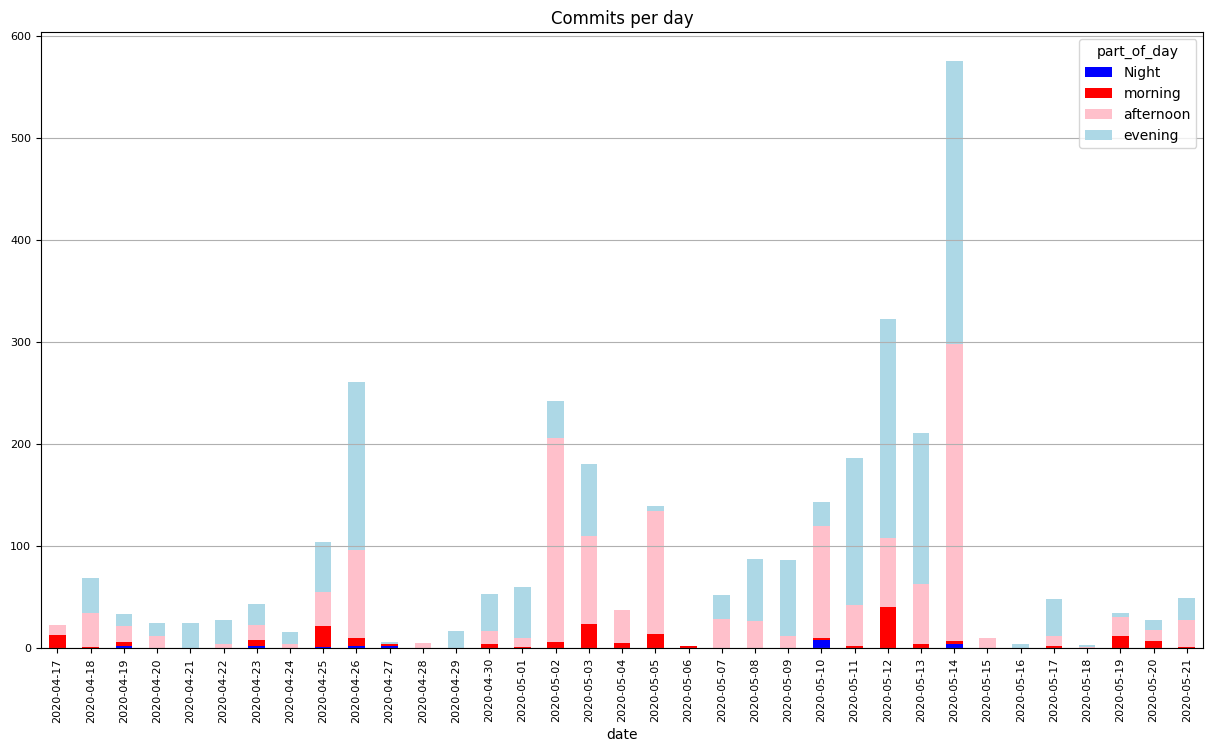

In [6]:
ax = df_grouped_time.plot(
    kind='bar',
    stacked=True,
    figsize=(15,8),
    fontsize=8,
    title='Commits per day',
    rot=90,
    color=['blue', 'red', 'pink', 'lightblue']
)

ax.grid(axis='y')

In [7]:
con.close()